# Применение больших языковых моделей для преобразования запросов на естественном языке в SQL-запросы к базам данных 1С:Предприятие

Проект решает задачу **Text-to-1C** — автоматический перевод запросов на естественном русском языке в язык запросов платформы 1С:Предприятие 8.3. Цель — позволить пользователям без технических знаний (бухгалтерам, учётчикам) формулировать запросы к базе данных простым языком.

Для первоначального эксперимента выбрана модель **`gpt-4o-mini`** (через OpenAI-совместимый прокси), как оптимальная по соотношению стоимость/качество. Ее наилучшая итоговая метрика EXS составила **0.78**, достигнутая в конфигурации `schema_adv_cot_vl_ef` (продвинутый промпт + Chain-of-Thought + Value Linking + Execution Feedback).

Для оценки качества перевода частично адаптирован датасет **Spider** (популярный бенчмарк Text-to-SQL) под специфику языка запросов 1С. Для конвертации SQL-схем в объекты конфигурации 1С и загрузки данных разработан отдельный модуль `tools/SQL-2-1C/`.


## 1. Рассмотренные подходы Text-to-SQL

На основе обзоров Text-to-SQL 2024–2025 составлен список из **15 техник**, применимых без дообучения модели (in-context learning). Из них **8 реализованы** в проекте, **7 осознанно отброшены**.

### 1.1. Реализованные подходы

| # | Подход | Академическое название | Статус | Описание |
|---|--------|------------------------|--------|----------|
| 1 | Правила 1С в промпте | Prompt engineering / rule injection | ✅ Включен | Добавление свода синтаксических правил языка запросов 1С в системный промпт LLM (ключевые слова, `ЗНАЧЕНИЕ()` для перечислений, `.Ссылка` у документов, `СрезПоследних()` для регистров). Базовый фундамент. |
| 2 | Chain-of-Thought | Prompt-based CoT | ✅ Включен | Требование к модели рассуждать пошагово перед генерацией финального запроса. Финальный код извлекается из тега `<query>`. |
| 3 | Query Plan | Query plan as intermediate repr. | ✅ Включен | Двухшаговая стратегия: сначала запрос на естественном языке к модели составить план, затем по плану сгенерировать код 1С. Взаимоисключающ с CoT. |
| 4 | Execution Feedback Loop | Execution-based feedback | ✅ Включен | Запрос выполняется в 1С через COM-мост. При ошибке — её текст возвращается в LLM для исправления. До 2 итераций. Ядро MAC-SQL Refiner. |
| 5 | Schema Linking | Schema linking (separate step) | ✅ Включен | Дополнительный LLM-вызов для отбора только релевантных объектов схемы. Сокращает контекст и убирает «шум» нерелевантных таблиц. |
| 6 | Value Linking | Value-based schema linking | ✅ Включен | Перед генерацией в схему добавляются примеры реальных значений из справочников 1С. Помогает LLM угадать формат хранения данных. |
| 7 | Multi-agent Critic | Self-Refine / Reflexion | ✅ Включен | После генерации отдельный LLM-вызов проверяет запрос на соответствие намерению пользователя и синтаксическую корректность. При замечаниях — перегенерация. |
| 8 | Prompt Engineering (вариации) | System prompt variations | ✅ Включен | Три уровня промпта: базовый, продвинутый полный (~10 КБ, 21 раздел + 8 примеров), продвинутый краткий (~2 КБ). Ablation-сравнение «полный vs краткий». |

### 1.2. Отложенные / отброшенные подходы

| # | Подход | Статус | Причина |
|---|--------|--------|---------|
| 9 | Few-shot retrieval (DAIL-SQL) | ❌ Отложен | Требует ручной сборки банка из 50–100 пар «вопрос → запрос». Для синтаксиса 1С трудозатратно собрать качественный generic-набор. |
| 10 | Self-consistency / Voting | ❌ Отброшен | Дорого: N LLM-вызовов + N выполнений в 1С на каждый запрос. Сложная нормализация результатов для голосования. |
| 11 | DIN-SQL декомпозиция | ❌ Отброшен | Реальные запросы одновременно попадают в несколько классов сложности (AGGREGATE + JOIN + VIRTUAL). Классификация легко запутывает модель. |
| 12 | QDecomp (подзапросы) | ❌ Отложен | В 1С жесткие ограничения на вложенность: `СрезПоследних` не вкладывается в виртуальные таблицы. Сборка подзапросов — нетривиальная инженерная задача. |
| 13 | Hybrid rules + LLM | ❌ Отброшен | Низкая научная ценность: шаблоны специфичны для конкретной базы, не обобщаются. Скорее продуктовая оптимизация. |
| 14 | Clarification + LLM user simulator | ❌ Отложен | Высокая научная ценность, но большой объем работы: симулятор-пользователя, датасет с эталонными ответами, протокол Bird-Interact. Тянет на отдельную главу. |
| 15 | Grammar-constrained decoding | ❌ Отброшен | Требует доступа к логитам/токенизатору (локальная модель + GBNF). Через OpenAI API недоступно. Для 1С нет готовой грамматики. |


## 2. Метрики оценки качества

Для количественной оценки используются **5 метрик**, покрывающих разные аспекты качества:

| Метрика | Полное название | Диапазон | Как считается |
|---------|----------------|----------|---------------|
| **EV** | Execution Validity | {0, 1} | 1 = запрос выполнился без ошибки в 1С, 0 = ошибка исполнения |
| **EX** | Execution Accuracy | {0, 1} | 1 = строки результата полностью совпадают с эталоном (без учета порядка); 0 = несовпадение или ошибка |
| **CM** | Component Matching | [0, 1] | F1-мера по пересечению множеств ключевых слов и объектных ссылок (справочники, документы, регистры) между сгенерированным и эталонным запросом |
| **SM** | Semantic Match | {0, 1} | LLM-судья (`gpt-4.1-mini`) проверяет, отвечает ли результат на исходный вопрос пользователя. Вызывается только при EV=1 и EX=0 (экономия API-вызовов) |
| **EXS** | EX or SM | {0, 1} | 1 если EX=1 или SM=1 — итоговая метрика семантической корректности |


## 3. Эксперименты и результаты

Проведено **12 экспериментов** с различными комбинациями модулей пайплайна на адаптированном бенчмарке (базовая конфигурация: `use_schema=true`, `advanced_prompt=true`). Модель: `gpt-4o-mini`.


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# === ЗАГРУЗКА ДАННЫХ ИЗ РЕЗУЛЬТАТОВ ===
import pathlib, glob, yaml

# Находим корень проекта
notebook_dir = pathlib.Path.cwd()
project_root = notebook_dir if (notebook_dir / "benchmarks").is_dir() else notebook_dir.parent
results_dir = project_root / "benchmarks" / "results"
config_file = project_root / "benchmarks" / "benchmark_config.yaml"

# Читаем конфиг для флагов модулей
with open(config_file, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
exp_info = {}
for e in cfg["experiments"]:
    exp_info[e["name"]] = {
        "model": e.get("model", ""),
        "use_schema": e.get("use_schema", False),
        "advanced_prompt": e.get("advanced_prompt", False),
        "advanced_short": e.get("advanced_short", False),
        "use_cot": e.get("use_cot", False),
        "use_query_plan": e.get("use_query_plan", False),
        "use_schema_linking": e.get("use_schema_linking", False),
        "use_value_linking": e.get("use_value_linking", False),
        "use_critic": e.get("use_critic", False),
        "use_exec_feedback": e.get("use_exec_feedback", False),
    }

# Читаем все файлы результатов
result_files = sorted(glob.glob(str(results_dir / "*.json")))
runs = []
for rf in result_files:
    with open(rf, "r", encoding="utf-8") as f:
        data = json.load(f)
    run_name = data["run_name"]
    questions = data["questions"]
    ev_vals = [q["ev"] for q in questions]
    ex_vals = [q["ex"] for q in questions]
    cm_vals = [q["cm"] for q in questions]
    sm_vals = [q["sm"] for q in questions]
    exs_vals = [q["exs"] for q in questions]
    info = exp_info.get(run_name, {})
    runs.append({
        "name": run_name,
        "model": info.get("model", data.get("model", "")),
        "timestamp": data.get("timestamp", ""),
        "num_questions": len(questions),
        "ev_mean": sum(ev_vals) / len(ev_vals),
        "ex_mean": sum(ex_vals) / len(ex_vals),
        "cm_mean": sum(cm_vals) / len(cm_vals),
        "sm_mean": sum(sm_vals) / len(sm_vals),
        "exs_mean": sum(exs_vals) / len(exs_vals),
        "modules": info,
    })

# Имена метрик
METRICS = ["ev", "ex", "cm", "sm", "exs"]
METRIC_LABELS = {
    "ev": "EV (Execution Valid)",
    "ex": "EX (Exact Match)",
    "cm": "CM (Cosine Match)",
    "sm": "SM (Semantic Match)",
    "exs": "EXS (EX or SM)"
}

MODULE_NAMES = [
    "advanced_prompt", "advanced_short", "use_cot", "use_query_plan",
    "use_schema_linking", "use_value_linking", "use_critic", "use_exec_feedback"
]
MODULE_LABELS = {
    "advanced_prompt": "Adv. Prompt",
    "advanced_short": "Adv. Short",
    "use_cot": "CoT",
    "use_query_plan": "QPlan",
    "use_schema_linking": "SchemaLink",
    "use_value_linking": "ValueLink",
    "use_critic": "Critic",
    "use_exec_feedback": "ExecFB"
}

print(f"Загружено {len(runs)} эксперимента(ов)")
for r in runs:
    print(f"  {r['name']}: EV={r['ev_mean']:.2f}, EX={r['ex_mean']:.2f}, CM={r['cm_mean']:.3f}, SM={r['sm_mean']:.2f}, EXS={r['exs_mean']:.2f}")

Загружено 12 эксперимента(ов)
  schema_adv: EV=0.46, EX=0.26, CM=0.656, SM=0.38, EXS=0.38
  schema_adv_cot: EV=0.52, EX=0.32, CM=0.654, SM=0.46, EXS=0.46
  schema_adv_cot_vl: EV=0.66, EX=0.44, CM=0.697, SM=0.60, EXS=0.60
  schema_adv_cot_vl_critic: EV=0.62, EX=0.46, CM=0.658, SM=0.58, EXS=0.58
  schema_adv_cot_vl_critic_ef: EV=0.72, EX=0.52, CM=0.675, SM=0.72, EXS=0.72
  schema_adv_cot_vl_ef: EV=0.78, EX=0.46, CM=0.706, SM=0.68, EXS=0.68
  schema_adv_critic: EV=0.42, EX=0.22, CM=0.623, SM=0.40, EXS=0.40
  schema_adv_ef: EV=0.68, EX=0.36, CM=0.678, SM=0.58, EXS=0.58
  schema_adv_qp: EV=0.56, EX=0.38, CM=0.622, SM=0.52, EXS=0.52
  schema_adv_short: EV=0.42, EX=0.24, CM=0.630, SM=0.36, EXS=0.36
  schema_adv_sl: EV=0.70, EX=0.28, CM=0.634, SM=0.58, EXS=0.58
  schema_adv_vl: EV=0.72, EX=0.44, CM=0.715, SM=0.66, EXS=0.66


### 3.1. Таблица экспериментов и включенных модулей

Каждая строка — один эксперимент. Колонки показывают, какие модули были активны (`+`). Справа — средние значения метрик.


In [2]:
# Строим таблицу: строки = эксперименты, колонки = модули + метрики
rows = []
for r in runs:
    row = {"Эксперимент": r["name"]}
    for m in MODULE_NAMES:
        row[MODULE_LABELS[m]] = "+" if r["modules"][m] else ""
    for metric in METRICS:
        row[f"{metric.upper()} (mean)"] = round(r[f"{metric}_mean"], 3)
    rows.append(row)

df = pd.DataFrame(rows)

# Стилизуем таблицу
styled = df.style.map(
    lambda v: "background-color: #c6efce; font-weight: bold" if v == "+" else "",
    subset=[MODULE_LABELS[m] for m in MODULE_NAMES]
).map(
    lambda v: "background-color: #ffeb9c" if isinstance(v, (int, float)) and v >= 0.7 else "" if isinstance(v, (int, float)) and v < 0.4 else "",
    subset=[f"{m.upper()} (mean)" for m in METRICS]
).set_properties(**{"text-align": "center"}).set_table_styles([
    {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
    {"selector": "td:first-child", "props": [("text-align", "left"), ("font-family", "monospace")]},
])

display(styled)
print(f"\nЛегенда: + = модуль включен; зеленый фон ≥0.7, желтый 0.4-0.7, без фона <0.4")

,Эксперимент,Adv. Prompt,Adv. Short,CoT,QPlan,SchemaLink,ValueLink,Critic,ExecFB,EV (mean),EX (mean),CM (mean),SM (mean),EXS (mean)
0,schema_adv,+,,,,,,,,0.460000,0.260000,0.656000,0.380000,0.380000
1,schema_adv_cot,+,,+,,,,,,0.520000,0.320000,0.654000,0.460000,0.460000
2,schema_adv_cot_vl,+,,+,,,+,,,0.660000,0.440000,0.697000,0.600000,0.600000
3,schema_adv_cot_vl_critic,+,,+,,,+,+,,0.620000,0.460000,0.658000,0.580000,0.580000
4,schema_adv_cot_vl_critic_ef,+,,+,,,+,+,+,0.720000,0.520000,0.675000,0.720000,0.720000
5,schema_adv_cot_vl_ef,+,,+,,,+,,+,0.780000,0.460000,0.706000,0.680000,0.680000
6,schema_adv_critic,+,,,,,,+,,0.420000,0.220000,0.623000,0.400000,0.400000
7,schema_adv_ef,+,,,,,,,+,0.680000,0.360000,0.678000,0.580000,0.580000
8,schema_adv_qp,+,,,+,,,,,0.560000,0.380000,0.622000,0.520000,0.520000
9,schema_adv_short,,+,,,,,,,0.420000,0.240000,0.630000,0.360000,0.360000



Легенда: + = модуль включен; зеленый фон ≥0.7, желтый 0.4-0.7, без фона <0.4


### 3.2. Барчарты по метрикам


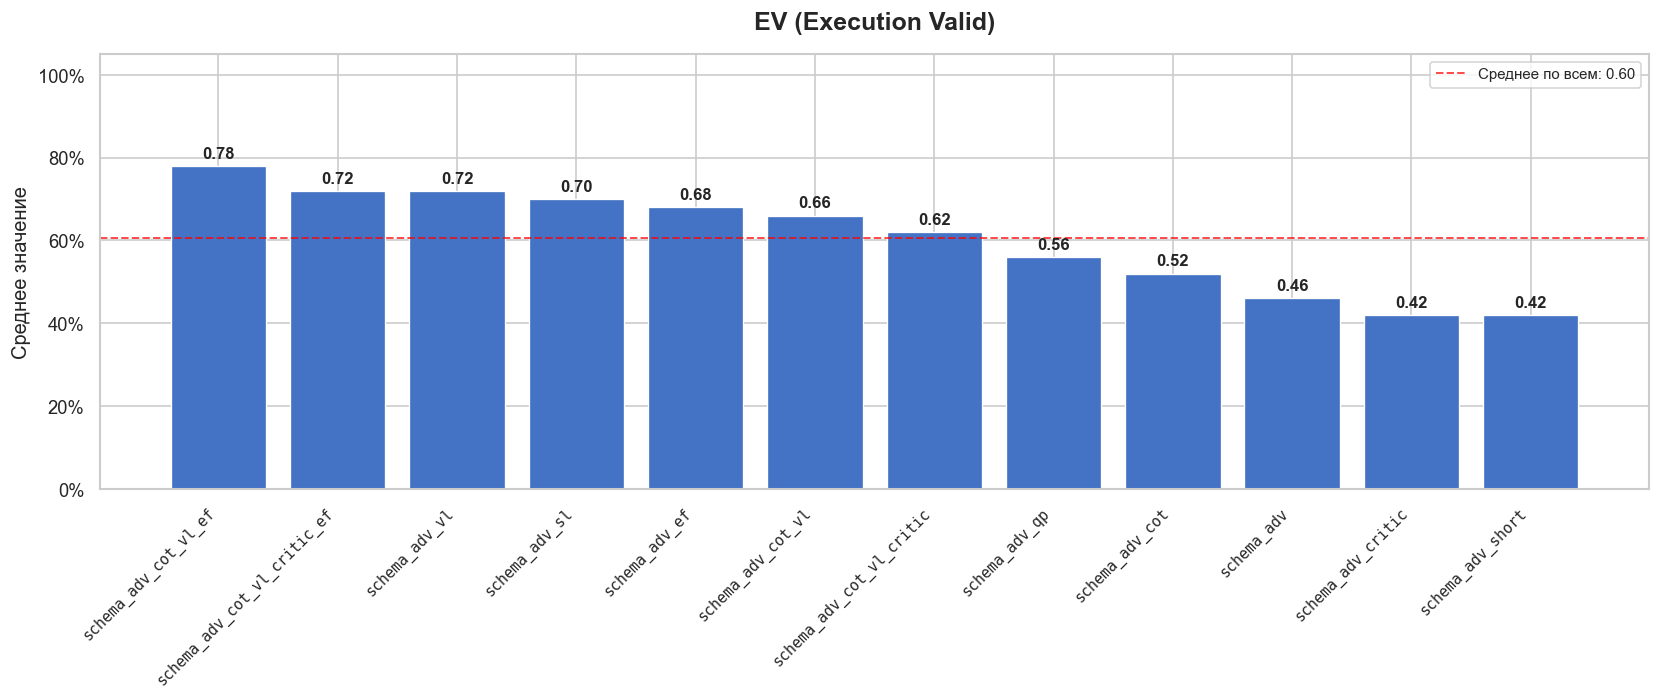

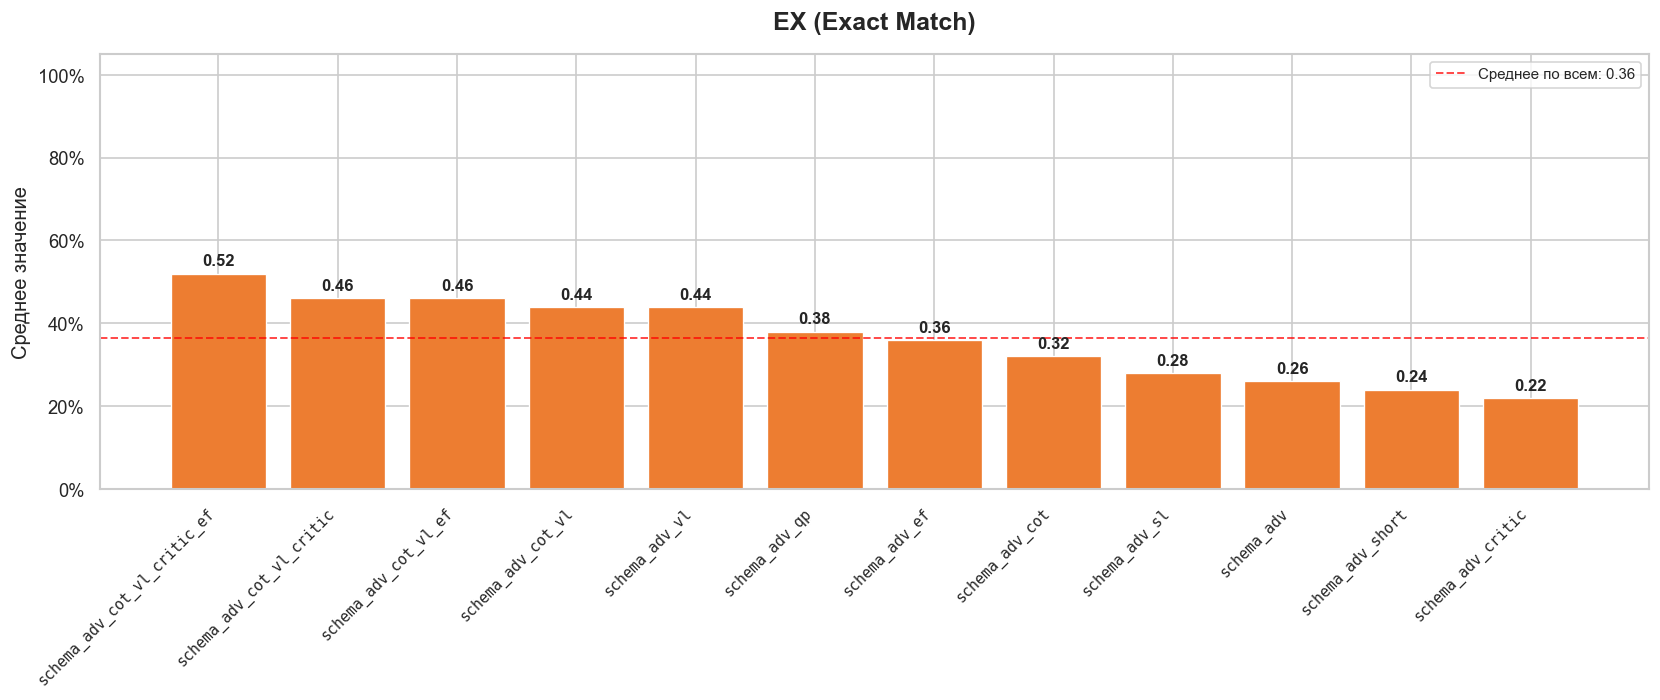

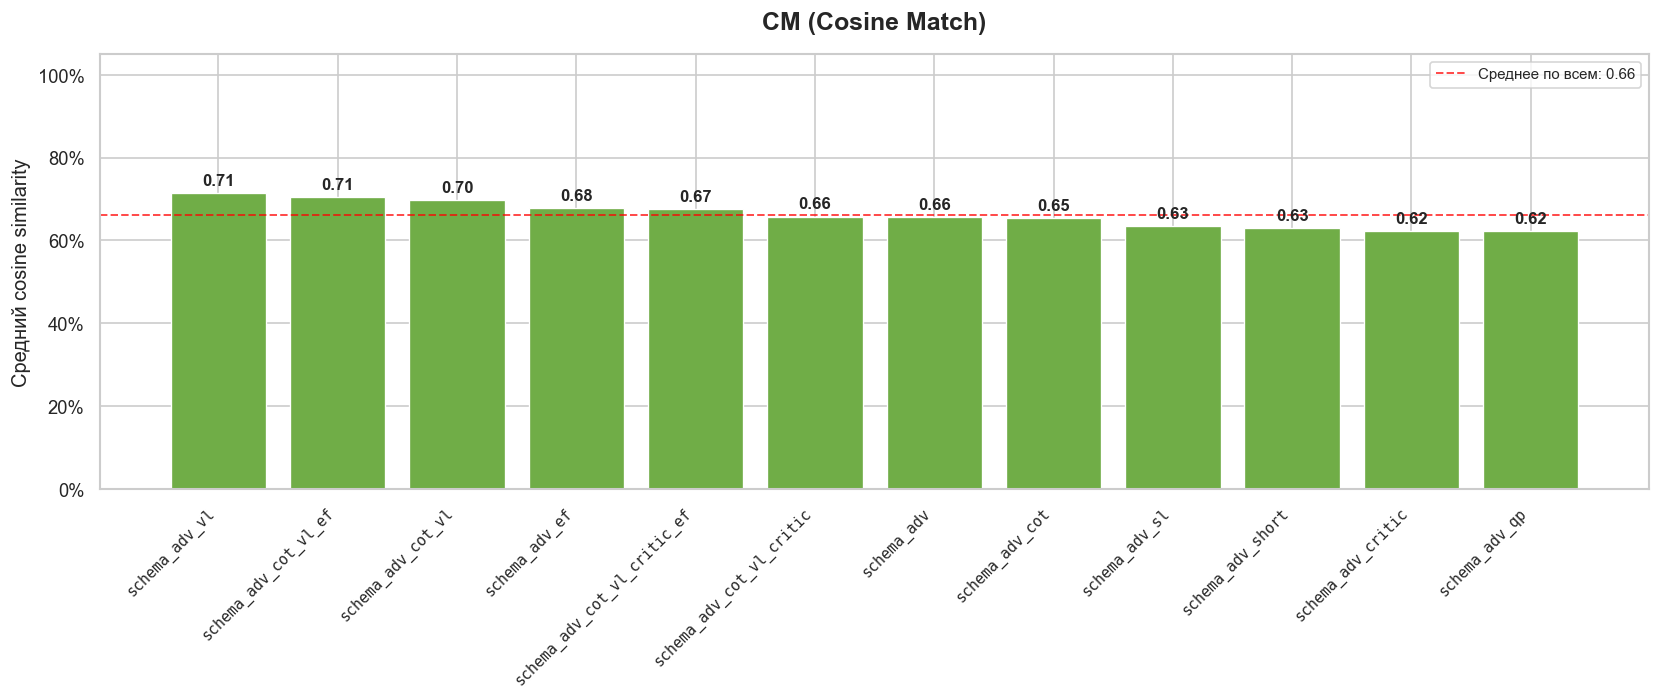

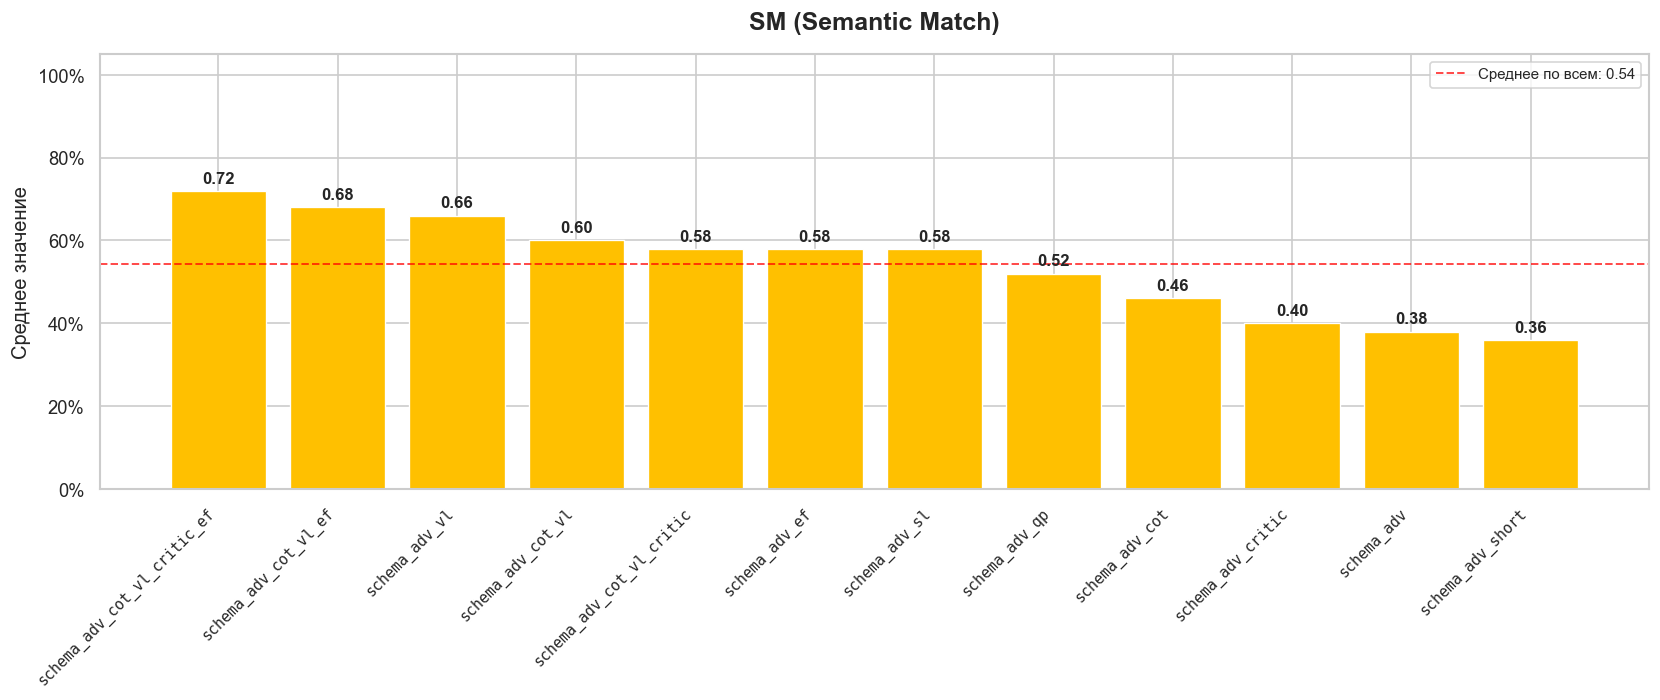

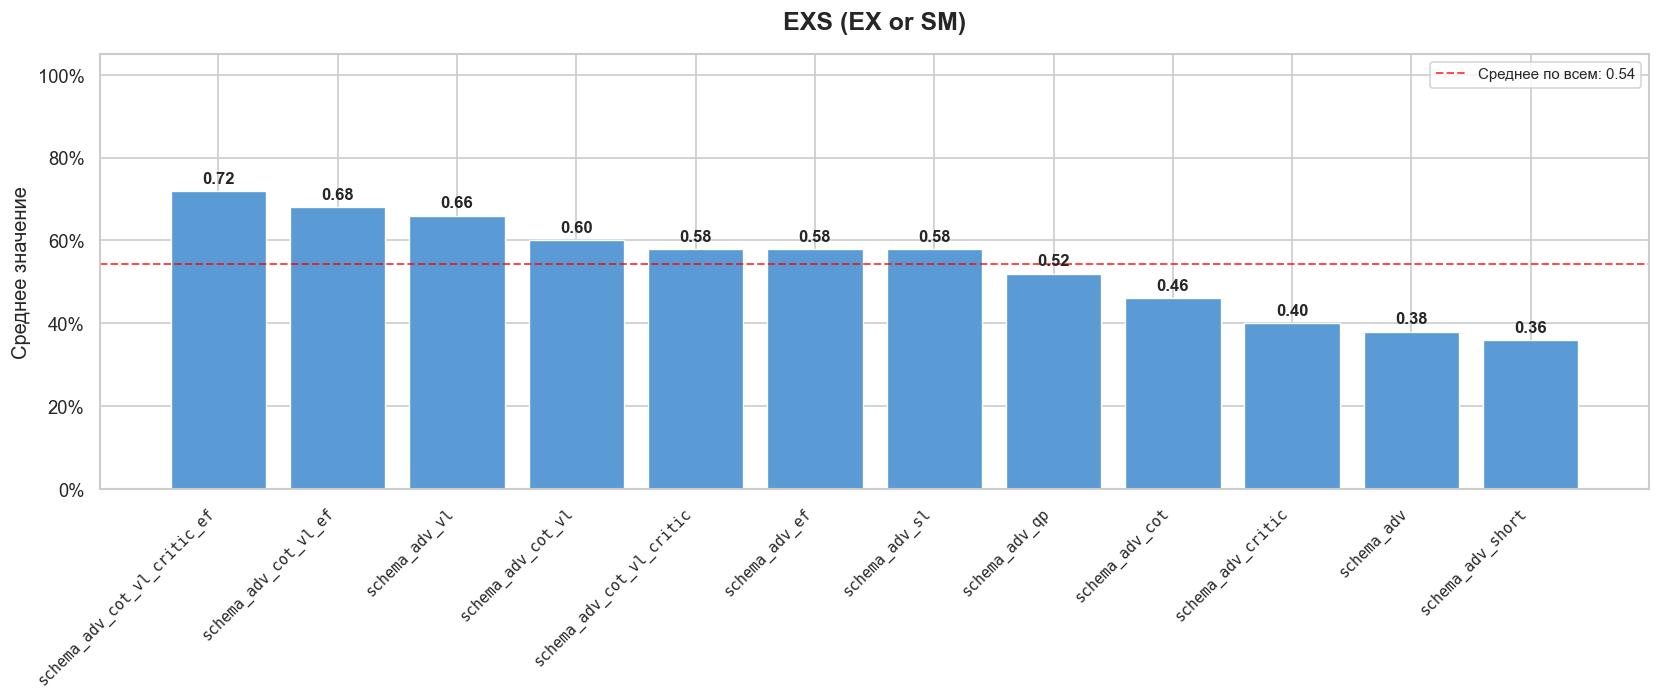

In [3]:
# Цветовая палитра для метрик
COLORS = ["#4472C4", "#ED7D31", "#70AD47", "#FFC000", "#5B9BD5"]

def plot_metric(metric_key, runs_data, color):
    """Построить барчарт для одной метрики."""
    label = METRIC_LABELS[metric_key]
    key = f"{metric_key}_mean"
    
    # Сортируем по убыванию значения
    sorted_runs = sorted(runs_data, key=lambda r: r[key], reverse=True)
    names = [r["name"] for r in sorted_runs]
    values = [r[key] for r in sorted_runs]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(range(len(names)), values, color=color, edgecolor="white", linewidth=0.8)
    
    # Подписи значений над столбцами
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9, family="monospace")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(label, fontsize=15, fontweight="bold", pad=15)
    ax.set_ylabel("Среднее значение" if metric_key != "cm" else "Средний cosine similarity")
    
    # Горизонтальная линия среднего по всем экспериментам
    mean_all = sum(v for v in values) / len(values)
    ax.axhline(y=mean_all, color="red", linestyle="--", linewidth=1.2, alpha=0.7,
              label=f"Среднее по всем: {mean_all:.2f}")
    ax.legend(loc="upper right", fontsize=9)
    
    plt.tight_layout()
    plt.show()

for i, metric in enumerate(METRICS):
    plot_metric(metric, runs, COLORS[i])

### 3.3. Сводный график: все метрики на одном поле


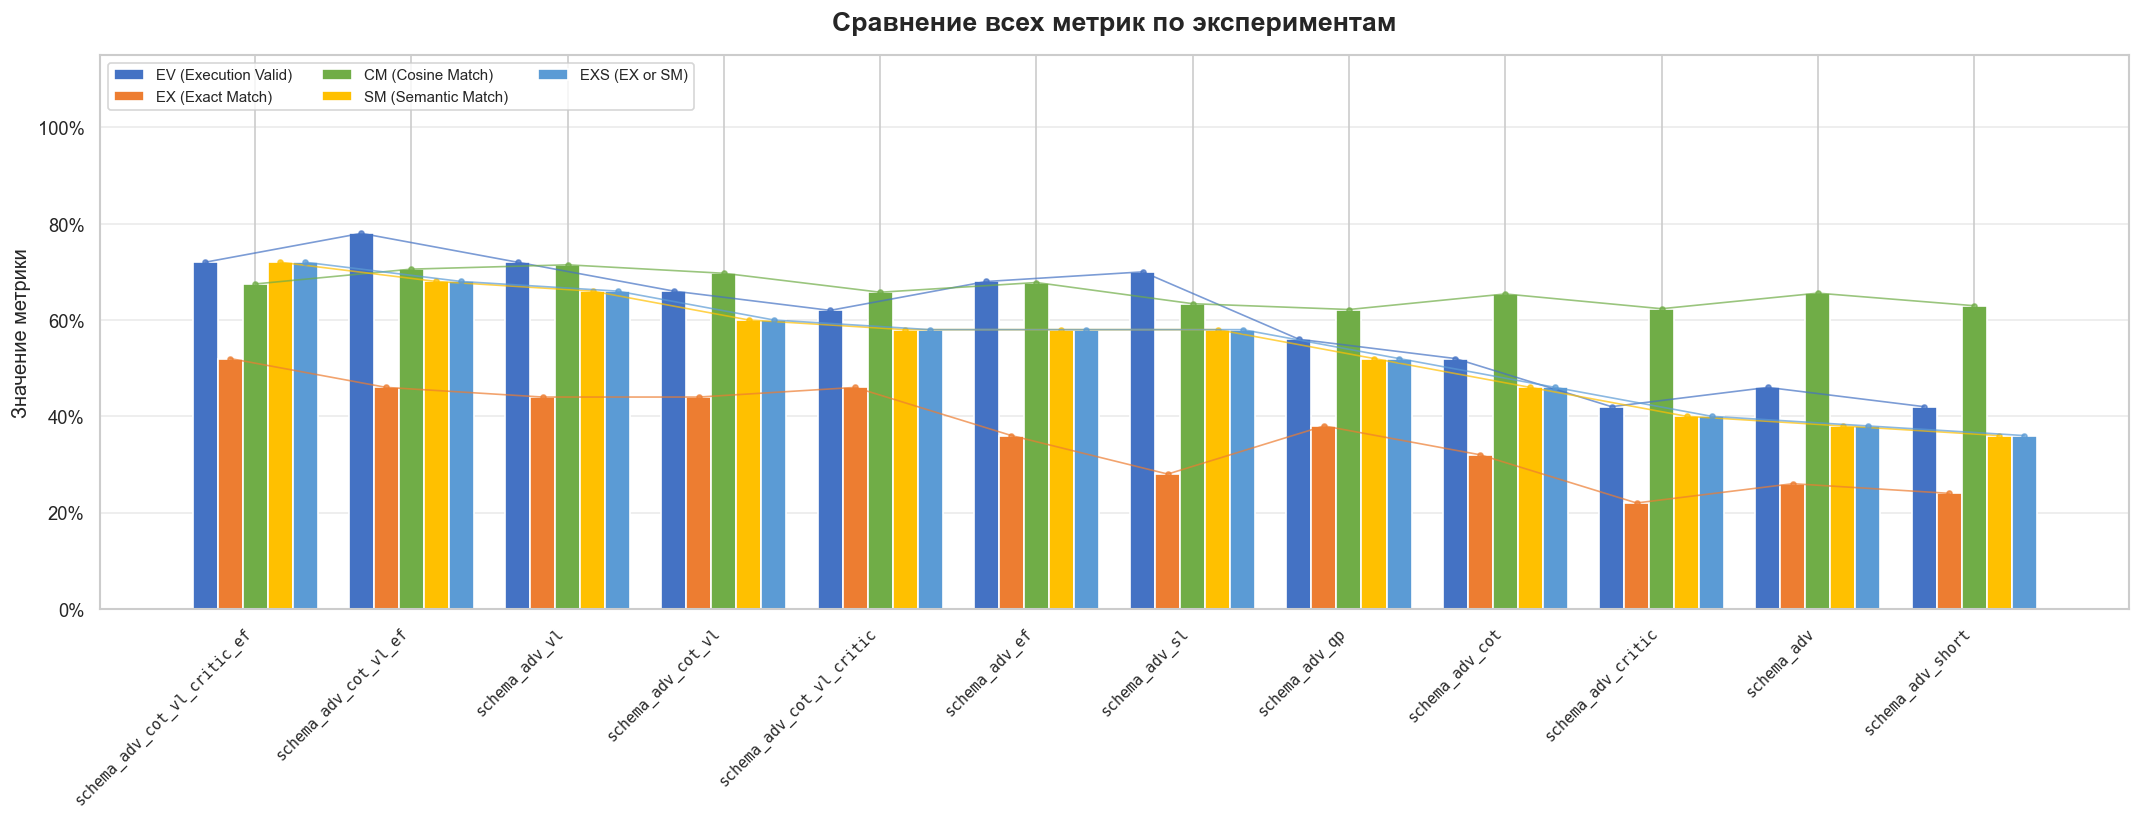

In [4]:
# Группированная столбчатая диаграмма по всем метрикам
# Сортируем по EXS (итоговой метрике)
sorted_runs = sorted(runs, key=lambda r: r["exs_mean"], reverse=True)
names = [r["name"] for r in sorted_runs]

x = range(len(names))
width = 0.16

fig, ax = plt.subplots(figsize=(18, 7))

for i, (metric, color) in enumerate(zip(METRICS, COLORS)):
    values = [r[f"{metric}_mean"] for r in sorted_runs]
    offset = (i - 2) * width
    bars = ax.bar([xi + offset for xi in x], values, width, label=METRIC_LABELS[metric], color=color, edgecolor="white")
    
    # Линия тренда (ломанная по вершинам)
    ax.plot([xi + offset for xi in x], values, "o-", color=color, markersize=3, linewidth=1, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9, family="monospace")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.15)
ax.set_title("Сравнение всех метрик по экспериментам", fontsize=16, fontweight="bold", pad=15)
ax.set_ylabel("Значение метрики")
ax.legend(loc="upper left", fontsize=9, ncol=3)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

### 3.4. Тепловая карта: метрики x эксперименты


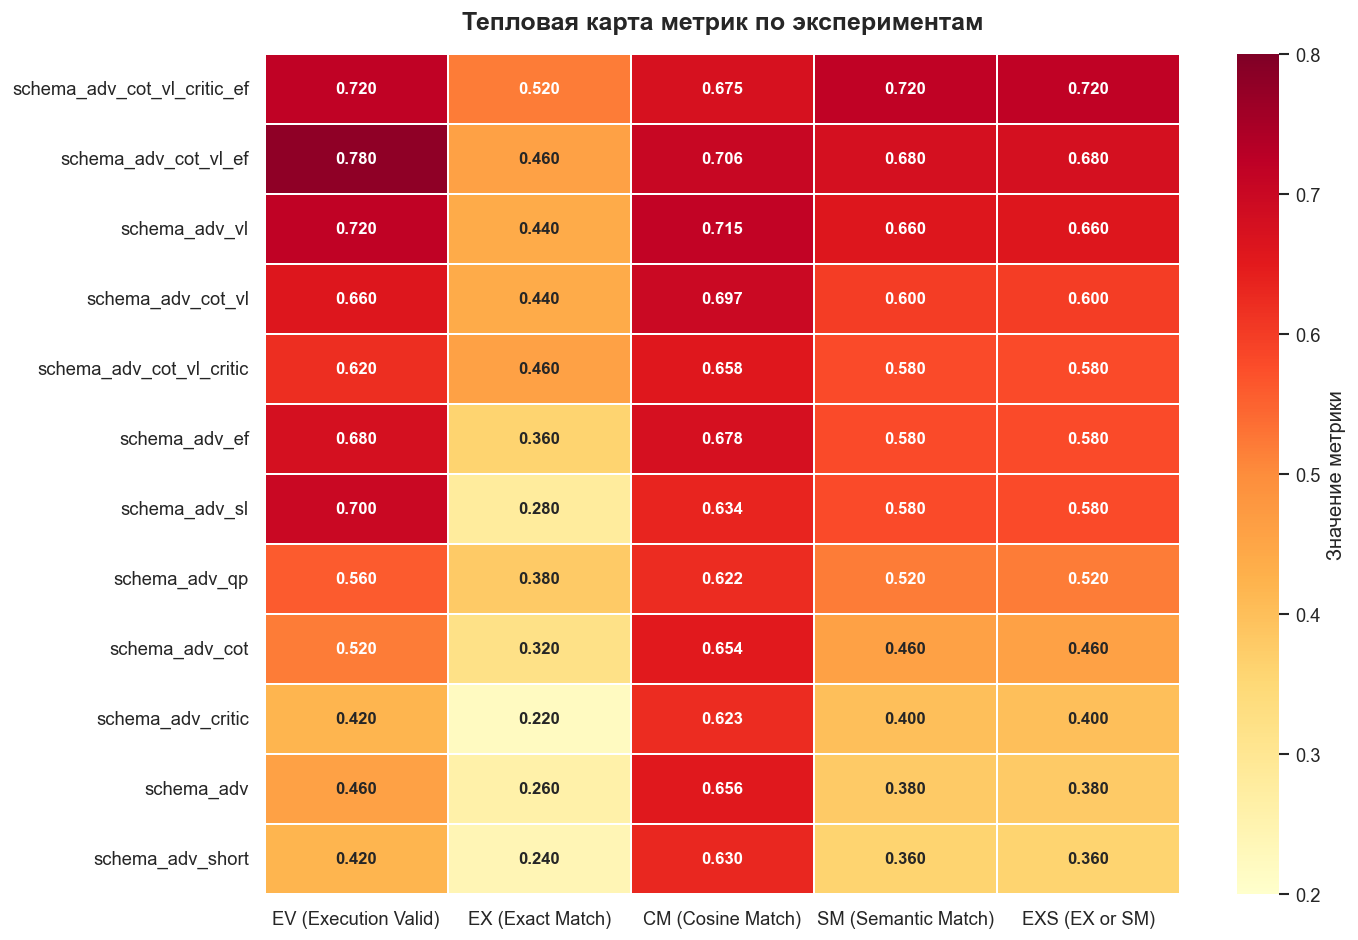

In [5]:
# Тепловая карта
hm_data = {METRIC_LABELS[m]: [round(r[f"{m}_mean"], 3) for r in sorted_runs] for m in METRICS}
hm_df = pd.DataFrame(hm_data, index=names)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(hm_df, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0.2, vmax=0.8,
            linewidths=1, linecolor="white", cbar_kws={"label": "Значение метрики"},
            annot_kws={"fontsize": 10, "fontweight": "bold"})
ax.set_title("Тепловая карта метрик по экспериментам", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 3.5. Топ-5 конфигураций по итоговой метрике EXS


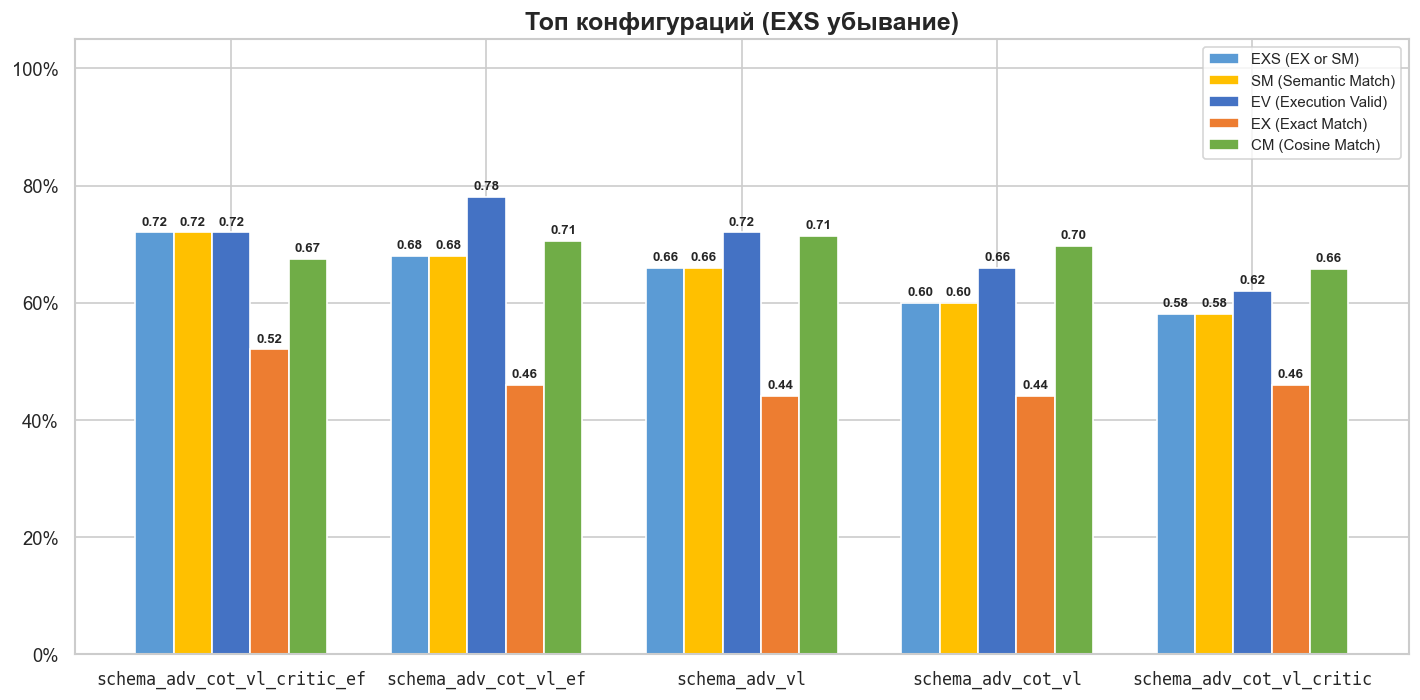

Топ-5 по EXS:
  #1 schema_adv_cot_vl_critic_ef: EXS=0.72 | модули: Adv. Prompt, CoT, ValueLink, Critic, ExecFB
  #2 schema_adv_cot_vl_ef: EXS=0.68 | модули: Adv. Prompt, CoT, ValueLink, ExecFB
  #3 schema_adv_vl: EXS=0.66 | модули: Adv. Prompt, ValueLink
  #4 schema_adv_cot_vl: EXS=0.60 | модули: Adv. Prompt, CoT, ValueLink
  #5 schema_adv_cot_vl_critic: EXS=0.58 | модули: Adv. Prompt, CoT, ValueLink, Critic


In [6]:
sorted_by_exs = sorted(runs, key=lambda r: r["exs_mean"], reverse=True)

fig, ax = plt.subplots(figsize=(12, 6))
top_n = min(5, len(sorted_by_exs))
top = sorted_by_exs[:top_n]

metrics_for_plot = ["exs", "sm", "ev", "ex", "cm"]
metric_colors_plot = ["#5B9BD5", "#FFC000", "#4472C4", "#ED7D31", "#70AD47"]

x = range(len(top))
width = 0.15

for i, (m, c) in enumerate(zip(metrics_for_plot, metric_colors_plot)):
    vals = [r[f"{m}_mean"] for r in top]
    offset = (i - 2) * width
    bars = ax.bar([xi + offset for xi in x], vals, width, label=METRIC_LABELS[m], color=c, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([r["name"] for r in top], fontsize=10, family="monospace")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.set_title("Топ конфигураций (EXS убывание)", fontsize=15, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print("Топ-5 по EXS:")
for i, r in enumerate(top):
    mods = [MODULE_LABELS[m] for m in MODULE_NAMES if r["modules"][m]]
    print(f"  #{i+1} {r['name']}: EXS={r['exs_mean']:.2f} | модули: {', '.join(mods)}")

## 4. Архитектура проекта

```
Text_2_1CQuery/
├── ui/app.py                     — Streamlit-интерфейс
├── pipeline/
│   ├── query_translator.py       — ядро перевода: системные промпты, вызов LLM
│   ├── schema_loader.py          — загрузка и кэширование Markdown-схемы базы
│   ├── xml_exporter.py           — выгрузка XML-конфигурации из 1С (DESIGNER)
│   ├── schema_compiler2.py       — XML → компактный Markdown (schema.md)
│   ├── schema_linker.py          — LLM-фильтр: отбор релевантных объектов схемы
│   ├── value_fetcher.py          — примеры значений из реальной базы 1С
│   ├── critic.py                 — агент-критик: проверка и перегенерация запроса
│   └── executor.py               — запуск 32-битного COM-моста к 1С
├── executor_bridge.py            — 32-битный COM-мост: выполняет запросы в 1С
├── llm_client.py                 — обертка OpenAI-совместимого API
├── config.py                     — список моделей, feature-флаги
├── benchmarks/
│   ├── runner.py                 — батч-раннер экспериментов
│   └── metrics.py                — вычисление EV, EX, CM, SM метрик
├── tools/SQL-2-1C/               — конвертер SQL-схем и данных → 1С
│   └── sql_to_1c.py              — парсер CREATE TABLE/INSERT → XML + load_data.os
├── databases/<key>/              — конфигурация и схема каждой базы 1С
├── spider_data/                  — датасет Spider (mini_spider)
└── research/                     — исследовательские заметки
```

**Двойное Python-окружение:** 64-битное (UI, LLM, анализ) + 32-битное (COM-мост к 1С 8.3 через `pywin32`). Связь между процессами — JSON через stdin/stdout.
